In [ ]:
!pip install kiwipiepy

In [ ]:
# ==============================================================================
# CNN 기반 하이브리드 피싱 탐지 모델 훈련 (Colab 실행용 최종본)
# ==============================================================================

# 0단계: 기본 설정 및 라이브러리 임포트
print("0단계: 기본 설정 시작")
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pickle
from tqdm import tqdm
import os
import warnings
from google.colab import drive
from kiwipiepy import Kiwi # CNN을 위한 토크나이저

warnings.filterwarnings('ignore')
print("0단계: 기본 설정 완료")

# 1단계: Colab 환경 설정 (드라이브 마운트, 필요 라이브러리 및 한글 폰트 설치)
print("\n1단계: Colab 환경 설정 시작")
try:
    drive.mount('/content/drive')
    !pip install kiwipiepy -q

    # 한글 폰트 설치 및 캐시 재생성 (가장 확실한 방법)
    !sudo apt-get install -y fonts-nanum*
    !sudo fc-cache -fv
    !rm ~/.cache/matplotlib -rf

    # 폰트 경로를 직접 지정하여 설정
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for font_file in font_files:
        fm.fontManager.addfont(font_file)
    plt.rc('font', family='NanumBarunGothic')
    plt.rc('axes', unicode_minus=False) # 마이너스 폰트 깨짐 방지
    print("1단계: Colab 환경 설정 완료 (드라이브 및 한글 폰트)")
except Exception as e:
    print(f"환경 설정 중 오류 발생: {e}")

0단계: 기본 설정 시작
0단계: 기본 설정 완료

1단계: Colab 환경 설정 시작
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'fonts-nanum-extra' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-coding' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-eco' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum' for glob 'fonts-nanum*'
fonts-nanum is already the newest version (20200506-1).
fonts-nanum-coding is already the newest version (2.5-3).
fonts-nanum-eco is already the newest version (1.000-7).
fonts-nanum-extra is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache con

In [ ]:
# ==============================================================================
# CNN 기반 하이브리드 피싱 탐지 모델 훈련 (Colab 실행용 최종본)
# ==============================================================================

# 0단계: 기본 설정 및 라이브러리 임포트
print("0단계: 기본 설정 시작")
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pickle
from tqdm import tqdm
import os
import warnings
from google.colab import drive
from kiwipiepy import Kiwi # CNN을 위한 토크나이저

warnings.filterwarnings('ignore')
print("0단계: 기본 설정 완료")
# ==============================================================================
# 1단계: Colab 환경 설정 (오류 수정본)
# ==============================================================================
print("\n 1단계: Colab 환경 설정 시작")
try:
    # --- Part 1: 필요 라이브러리 설치 ---
    print("--- 라이브러리 설치 중 (kiwipiepy)...")
    !pip install kiwipiepy -q
    print("--- 라이브-러리 설치 완료 ---")

    # --- Part 2: 구글 드라이브 마운트 ---
    from google.colab import drive
    print("--- 구글 드라이브 마운트 중...")
    drive.mount('/content/drive', force_remount=True)
    print("--- 드라이브 마운트 완료 ---")

    # --- Part 3: 한글 폰트 설치 및 Matplotlib 설정 ---
    import matplotlib.pyplot as plt
    import matplotlib.font_manager as fm

    print("--- 한글 폰트 설치 중...")
    # 폰트 설치 셸 명령어 실행
    !sudo apt-get -y install fonts-nanum*
    !sudo fc-cache -fv
    !rm ~/.cache/matplotlib -rf
    print("--- 폰트 설치 완료 ---")

    # Matplotlib에 폰트 경로 알려주기 및 설정
    print("--- Matplotlib 폰트 설정 중...")
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for font_file in font_files:
        fm.fontManager.addfont(font_file)

    plt.rc('font', family='NanumBarunGothic')
    plt.rc('axes', unicode_minus=False) # 마이너스 폰트 깨짐 방지
    print("--- 폰트 설정 완료 ---")

    print("\n 1단계: Colab 환경 설정 모두 성공적으로 완료되었습니다.")

except Exception as e:
    print(f"\n 1단계 환경 설정 중 오류가 발생했습니다: {e}")
    print("오류가 발생했지만, 필요한 경우 다음 단계를 계속 진행할 수 있습니다.")

# 2단계: 데이터 및 경로 설정
print("\n2단계: 데이터 경로 설정")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

base_path = "/content/drive/MyDrive/"
phishing_path = os.path.join(base_path, "phishing_6000_final.csv")
normal_path = os.path.join(base_path, "normal_6000_final.csv")
test1_path = os.path.join(base_path, "1차모델_테스트데이터셋.csv")
test2_path = os.path.join(base_path, "시나리오테스트셋_60.csv")
SAVE_DIR = os.path.join(base_path, "CNN_Hybrid_Model")
os.makedirs(SAVE_DIR, exist_ok=True)
print("2단계: 데이터 경로 설정 완료")

# 3단계: 데이터 로드
print("\n3단계: 데이터 로드 시작")
df_phish = pd.read_csv(phishing_path)
df_normal = pd.read_csv(normal_path)
df_train = pd.concat([df_phish, df_normal], ignore_index=True)
df_train.dropna(subset=["text"], inplace=True)
print(f"전체 훈련 데이터: {len(df_train)}개")
print("3단계: 데이터 로드 완료")


# 4단계: N-gram 특성 추출기 (앙상블용, 수정 없음)
class NgramFeatureExtractor:
    def __init__(self):
        self.tfidf_unigram = TfidfVectorizer(max_features=5000, ngram_range=(1, 1))
        self.tfidf_bigram = TfidfVectorizer(max_features=3000, ngram_range=(2, 2))
        self.tfidf_trigram = TfidfVectorizer(max_features=2000, ngram_range=(3, 3))
        self.char_ngram = TfidfVectorizer(max_features=3000, ngram_range=(2, 4), analyzer='char')
        self.fitted = False

    def fit(self, texts):
        print("N-gram 특성 추출기 훈련 중...")
        self.tfidf_unigram.fit(texts); self.tfidf_bigram.fit(texts)
        self.tfidf_trigram.fit(texts); self.char_ngram.fit(texts)
        self.fitted = True

    def transform(self, texts):
        if not self.fitted: raise ValueError("특성 추출기가 훈련되지 않았습니다.")
        features = [
            self.tfidf_unigram.transform(texts), self.tfidf_bigram.transform(texts),
            self.tfidf_trigram.transform(texts), self.char_ngram.transform(texts)
        ]
        return hstack(features)

# 5단계: [신규] CNN을 위한 토크나이저 및 단어사전 클래스
class CNTokenizer:
    def __init__(self, max_vocab_size=30000):
        self.kiwi = Kiwi()
        self.max_vocab_size = max_vocab_size
        self.word2idx = {'<pad>': 0, '<unk>': 1}
        self.idx2word = {0: '<pad>', 1: '<unk>'}
        self.fitted = False

    def fit(self, texts):
        print("CNN 토크나이저 단어사전 구축 중...")
        word_counts = {}
        for text in tqdm(texts, desc="단어 빈도 계산"):
            tokens = [token.form for token in self.kiwi.tokenize(text)]
            for token in tokens:
                word_counts[token] = word_counts.get(token, 0) + 1

        sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
        for i, (word, _) in enumerate(sorted_words[:self.max_vocab_size-2]):
            self.word2idx[word] = i + 2
            self.idx2word[i + 2] = word
        self.fitted = True

    def texts_to_sequences(self, texts):
        if not self.fitted: raise ValueError("토크나이저가 훈련되지 않았습니다.")
        sequences = []
        for text in texts:
            tokens = [token.form for token in self.kiwi.tokenize(text)]
            seq = [self.word2idx.get(token, self.word2idx['<unk>']) for token in tokens]
            sequences.append(seq)
        return sequences

    @property
    def vocab_size(self):
        return len(self.word2idx)

# 6단계: [수정] CNN에 맞는 데이터셋 클래스
class PhishingDatasetCNN(Dataset):
    def __init__(self, sequences, labels, max_length=512):
        self.sequences = sequences; self.labels = labels; self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        label = self.labels[idx]

        # 패딩 및 자르기
        if len(seq) > self.max_length:
            seq = seq[:self.max_length]
        else:
            seq = seq + [0] * (self.max_length - len(seq)) # 0은 <pad> 토큰

        return {'input_ids': torch.tensor(seq, dtype=torch.long), 'label': torch.tensor(label, dtype=torch.long)}

# 7단계: [신규] CNN 분류 모델 정의 (효율 극대화)
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, num_filters=150, kernel_sizes=[3,4,5], dropout=0.5, n_classes=2):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=ks)
            for ks in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(kernel_sizes) * num_filters, n_classes)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids).permute(0, 2, 1) # (B, EmbDim, SeqLen)
        conved = [F.relu(conv(embedded)) for conv in self.convs]
        pooled = [F.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]
        cat = self.dropout(torch.cat(pooled, dim=1))
        return self.fc(cat)

# 8단계: [수정] CNN 기반 앙상블 모델 클래스
class EnsemblePhishingDetectorCNN:
    def __init__(self, cnn_model, ngram_extractor):
        self.cnn_model = cnn_model; self.ngram_extractor = ngram_extractor
        self.rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
        self.lr_model = LogisticRegression(C=1.0, random_state=42, max_iter=1000)
        self.svm_model = SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
        self.fitted = False

    def fit_traditional_models(self, texts, labels):
        print("전통적 ML 모델 훈련 중..."); features = self.ngram_extractor.transform(texts)
        self.rf_model.fit(features, labels); self.lr_model.fit(features, labels); self.svm_model.fit(features, labels)
        self.fitted = True

    def predict_ensemble(self, tokenized_texts_for_cnn, raw_texts_for_ngram, cnn_probabilities):
        if not self.fitted: raise ValueError("전통적 모델들이 훈련되지 않았습니다.")
        features = self.ngram_extractor.transform(raw_texts_for_ngram)
        rf_pred_proba = self.rf_model.predict_proba(features)[:, 1]
        lr_pred_proba = self.lr_model.predict_proba(features)[:, 1]
        svm_pred_proba = self.svm_model.predict_proba(features)[:, 1]
        ensemble_proba = (0.5 * cnn_probabilities + 0.2 * rf_pred_proba + 0.2 * lr_pred_proba + 0.1 * svm_pred_proba)
        return (ensemble_proba >= 0.5).astype(int), ensemble_proba

# 9단계: 모델 훈련 함수 (수정 없음)
def train_model(model, train_loader, val_loader, epochs=5, learning_rate=2e-5):
    print("\n" + "="*60 + "\n딥러닝 모델 훈련 시작\n" + "="*60)
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01, eps=1e-8)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(); best_f1 = 0; best_model_state = None
    for epoch in range(epochs):
        print(f"\n{'='*20} Epoch {epoch+1}/{epochs} {'='*20}"); model.train(); total_train_loss = 0
        train_progress = tqdm(train_loader, desc="훈련 진행")
        for batch in train_progress:
            optimizer.zero_grad()
            input_ids, labels = batch['input_ids'].to(device), batch['label'].to(device)
            outputs = model(input_ids=input_ids); loss = criterion(outputs, labels)
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0); optimizer.step()
            total_train_loss += loss.item(); train_progress.set_postfix({'loss': f'{loss.item():.4f}'})

        scheduler.step(); avg_train_loss = total_train_loss / len(train_loader)
        model.eval(); val_predictions, val_true_labels = [], []
        with torch.no_grad():
            for batch in tqdm(val_loader, desc="검증 진행"):
                input_ids, labels = batch['input_ids'].to(device), batch['label'].to(device)
                outputs = model(input_ids=input_ids)
                predictions = torch.argmax(outputs, dim=1)
                val_predictions.extend(predictions.cpu().numpy()); val_true_labels.extend(labels.cpu().numpy())

        val_f1 = f1_score(val_true_labels, val_predictions, zero_division=0)
        print(f"훈련 손실: {avg_train_loss:.4f}, 검증 F1-Score: {val_f1:.4f}")
        if val_f1 > best_f1:
            best_f1 = val_f1; best_model_state = model.state_dict().copy()
            print(f"*** 최고 F1-Score 달성: {best_f1:.4f} ***")

    if best_model_state: model.load_state_dict(best_model_state)
    return model

# 10단계: 예측 함수 (수정)
def predict_batch_cnn(model, data_loader):
    model.eval(); predictions, probabilities = [], []
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="예측 진행"):
            input_ids = batch['input_ids'].to(device)
            outputs = model(input_ids=input_ids)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            predictions.extend(preds.cpu().numpy()); probabilities.extend(probs[:, 1].cpu().numpy())
    return np.array(predictions), np.array(probabilities)


# ==============================================================================
# 메인 실행 로직
# ==============================================================================
print("\n" + "="*60 + "\n메인 실행 로직 시작\n" + "="*60)

# 11. 데이터 준비 및 분할
X_text = df_train["text"].astype(str).tolist(); y = df_train["is_phishing"].values
X_train_text, X_val_text, y_train, y_val = train_test_split(X_text, y, test_size=0.2, random_state=42, stratify=y)

# 12. CNN 토크나이저 및 N-gram 추출기 훈련
tokenizer = CNTokenizer(); tokenizer.fit(X_train_text)
ngram_extractor = NgramFeatureExtractor(); ngram_extractor.fit(X_train_text)

# 13. 텍스트를 시퀀스로 변환
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)

# 14. 데이터로더 생성
BATCH_SIZE = 8; MAX_LENGTH = 512
train_dataset = PhishingDatasetCNN(X_train_seq, y_train, MAX_LENGTH)
val_dataset = PhishingDatasetCNN(X_val_seq, y_val, MAX_LENGTH)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 15. CNN 모델 생성 및 훈련
cnn_model = TextCNN(vocab_size=tokenizer.vocab_size)
cnn_model = train_model(cnn_model, train_loader, val_loader, epochs=5, learning_rate=2e-5)

# 16. 앙상블 모델 생성 및 훈련
ensemble_detector = EnsemblePhishingDetectorCNN(cnn_model, ngram_extractor)
ensemble_detector.fit_traditional_models(X_train_text, y_train)

# 17. 모델 저장
print("\n" + "="*60 + "\n모델 저장\n" + "="*60)
model_save_path = os.path.join(SAVE_DIR, "cnn_model.pt")
tokenizer_save_path = os.path.join(SAVE_DIR, "cnn_tokenizer.pkl")
ngram_save_path = os.path.join(SAVE_DIR, "ngram_extractor.pkl")
ensemble_save_path = os.path.join(SAVE_DIR, "ensemble_detector_cnn.pkl")

torch.save(cnn_model.state_dict(), model_save_path)
with open(tokenizer_save_path, 'wb') as f: pickle.dump(tokenizer, f)
with open(ngram_save_path, 'wb') as f: pickle.dump(ngram_extractor, f)
with open(ensemble_save_path, 'wb') as f: pickle.dump(ensemble_detector, f)
print(f"CNN 모델 저장: {model_save_path}\n토크나이저 저장: {tokenizer_save_path}")
print(f"N-gram 추출기 저장: {ngram_save_path}\n앙상블 탐지기 저장: {ensemble_save_path}")

# 18. 테스트 데이터 평가 함수
def evaluate_test_data_cnn(test_path, test_name, cnn_model, ensemble_detector):
    print(f"\n{'='*20} {test_name} 평가 시작 {'='*20}")
    df_test = pd.read_csv(test_path).dropna(subset=["text", "is_phishing"])
    X_test_text = df_test["text"].astype(str).tolist(); y_test = df_test["is_phishing"].values
    if len(X_test_text) == 0: print("테스트 데이터가 비어있습니다."); return

    X_test_seq = tokenizer.texts_to_sequences(X_test_text)
    test_dataset = PhishingDatasetCNN(X_test_seq, y_test, MAX_LENGTH)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print("CNN 모델 예측 진행 중...")
    cnn_pred, cnn_proba = predict_batch_cnn(cnn_model, test_loader)

    print("앙상블 예측 진행 중...")
    ensemble_pred, _ = ensemble_detector.predict_ensemble(X_test_seq, X_test_text, cnn_proba)

    print(f"\n{'='*15} CNN 모델 결과 {'='*15}"); print(classification_report(y_test, cnn_pred, target_names=['정상', '피싱']))
    print(f"\n{'='*15} 앙상블 모델 결과 {'='*15}"); print(classification_report(y_test, ensemble_pred, target_names=['정상', '피싱']))

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'「 {test_name} 」 평가 결과', fontsize=20, y=1.02)

    sns.heatmap(confusion_matrix(y_test, cnn_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 14})
    axes[0].set_title('CNN 모델 혼동 행렬', fontsize=16)
    axes[0].set_xlabel('예측 레이블', fontsize=12)
    axes[0].set_ylabel('실제 레이블', fontsize=12)

    sns.heatmap(confusion_matrix(y_test, ensemble_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1], annot_kws={"size": 14})
    axes[1].set_title('앙상블 모델 혼동 행렬', fontsize=16)
    axes[1].set_xlabel('예측 레이블', fontsize=12)
    axes[1].set_ylabel('실제 레이블', fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

# 19. 테스트 데이터셋 평가 실행
evaluate_test_data_cnn(test1_path, "1차모델 테스트데이터셋", cnn_model, ensemble_detector)
evaluate_test_data_cnn(test2_path, "시나리오통화 테스트셋", cnn_model, ensemble_detector)

print("\n" + "="*60 + "\n모든 프로세스 완료\n" + "="*60)

0단계: 기본 설정 시작
0단계: 기본 설정 완료

 1단계: Colab 환경 설정 시작
--- 라이브러리 설치 중 (kiwipiepy)...
--- 라이브-러리 설치 완료 ---
--- 구글 드라이브 마운트 중...
Mounted at /content/drive
--- 드라이브 마운트 완료 ---
--- 한글 폰트 설치 중...
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'fonts-nanum-extra' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-coding' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-eco' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum' for glob 'fonts-nanum*'
fonts-nanum is already the newest version (20200506-1).
fonts-nanum-coding is already the newest version (2.5-3).
fonts-nanum-eco is already the newest version (1.000-7).
fonts-nanum-extra is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new c

단어 빈도 계산: 100%|██████████| 9600/9600 [06:55<00:00, 23.10it/s]


N-gram 특성 추출기 훈련 중...

딥러닝 모델 훈련 시작

==================== Epoch 1/5 ====================


검증 진행: 100%|██████████| 300/300 [00:33<00:00,  8.97it/s]


훈련 손실: 0.3013, 검증 F1-Score: 0.9847
*** 최고 F1-Score 달성: 0.9847 ***

==================== Epoch 2/5 ====================


...

검증 진행: 100%|██████████| 300/300 [00:33<00:00,  9.04it/s]


훈련 손실: 0.0302, 검증 F1-Score: 0.9896
*** 최고 F1-Score 달성: 0.9896 ***

==================== Epoch 5/5 ====================


검증 진행: 100%|██████████| 300/300 [00:34<00:00,  8.72it/s]


훈련 손실: 0.0250, 검증 F1-Score: 0.9892
전통적 ML 모델 훈련 중...

모델 저장


TypeError: cannot pickle 'Kiwi' object

In [1]:
# ==============================================================================
# CNN 기반 하이브리드 피싱 탐지 모델 훈련 (Colab 실행용 최종본)
# 오류 수정 완료 버전
# ==============================================================================

# 0단계: 기본 설정 및 라이브러리 임포트
print("0단계: 기본 설정 시작")
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pickle
from tqdm import tqdm
import os
import warnings
from google.colab import drive
from kiwipiepy import Kiwi # CNN을 위한 토크나이저

warnings.filterwarnings('ignore')
print("0단계: 기본 설정 완료")

# 1단계: Colab 환경 설정
print("\n1단계: Colab 환경 설정 시작")
try:
    drive.mount('/content/drive', force_remount=True)
    !pip install kiwipiepy -q
    !sudo apt-get install -y fonts-nanum* > /dev/null
    !sudo fc-cache -fv > /dev/null
    !rm ~/.cache/matplotlib -rf

    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for font_file in font_files:
        fm.fontManager.addfont(font_file)
    plt.rc('font', family='NanumBarunGothic')
    plt.rc('axes', unicode_minus=False)
    print("1단계: Colab 환경 설정 완료")
except Exception as e:
    print(f"환경 설정 중 오류 발생: {e}")

# 2단계: 데이터 및 경로 설정
print("\n2단계: 데이터 경로 설정")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

base_path = "/content/drive/MyDrive/"
phishing_path = os.path.join(base_path, "phishing_6000_final.csv")
normal_path = os.path.join(base_path, "normal_6000_final.csv")
test1_path = os.path.join(base_path, "1차모델_테스트데이터셋.csv")
test2_path = os.path.join(base_path, "시나리오테스트셋_60.csv") # 파일명에 오타가 있을 수 있어 확인 필요
SAVE_DIR = os.path.join(base_path, "CNN_Hybrid_Model")
os.makedirs(SAVE_DIR, exist_ok=True)
print("2단계: 데이터 경로 설정 완료")

# 3단계: 데이터 로드
print("\n3단계: 데이터 로드 시작")
df_phish = pd.read_csv(phishing_path)
df_normal = pd.read_csv(normal_path)
df_train = pd.concat([df_phish, df_normal], ignore_index=True)
df_train.dropna(subset=["text"], inplace=True)
print(f"전체 훈련 데이터: {len(df_train)}개")
print("3단계: 데이터 로드 완료")


# 4단계: N-gram 특성 추출기
class NgramFeatureExtractor:
    def __init__(self):
        self.tfidf_unigram = TfidfVectorizer(max_features=5000, ngram_range=(1, 1))
        self.tfidf_bigram = TfidfVectorizer(max_features=3000, ngram_range=(2, 2))
        self.tfidf_trigram = TfidfVectorizer(max_features=2000, ngram_range=(3, 3))
        self.char_ngram = TfidfVectorizer(max_features=3000, ngram_range=(2, 4), analyzer='char')
        self.fitted = False

    def fit(self, texts):
        print("N-gram 특성 추출기 훈련 중...")
        self.tfidf_unigram.fit(texts); self.tfidf_bigram.fit(texts)
        self.tfidf_trigram.fit(texts); self.char_ngram.fit(texts)
        self.fitted = True

    def transform(self, texts):
        if not self.fitted: raise ValueError("특성 추출기가 훈련되지 않았습니다.")
        features = [
            self.tfidf_unigram.transform(texts), self.tfidf_bigram.transform(texts),
            self.tfidf_trigram.transform(texts), self.char_ngram.transform(texts)
        ]
        return hstack(features)

# ==============================================================================
# 5단계: [수정] CNN 토크나이저 (pickle 저장을 위해 __getstate__, __setstate__ 추가)
# ==============================================================================
class CNTokenizer:
    def __init__(self, max_vocab_size=30000):
        self.kiwi = Kiwi()
        self.max_vocab_size = max_vocab_size
        self.word2idx = {'<pad>': 0, '<unk>': 1}
        self.idx2word = {0: '<pad>', 1: '<unk>'}
        self.fitted = False

    def __getstate__(self):
        # 저장 시 kiwi 객체를 제외한 나머지 상태를 저장
        state = self.__dict__.copy()
        del state['kiwi']
        return state

    def __setstate__(self, state):
        # 로드 시 저장된 상태를 복원하고 kiwi 객체를 새로 생성
        self.__dict__.update(state)
        self.kiwi = Kiwi()

    def fit(self, texts):
        print("CNN 토크나이저 단어사전 구축 중...")
        word_counts = {}
        for text in tqdm(texts, desc="단어 빈도 계산"):
            tokens = [token.form for token in self.kiwi.tokenize(text)]
            for token in tokens:
                word_counts[token] = word_counts.get(token, 0) + 1

        sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
        for i, (word, _) in enumerate(sorted_words[:self.max_vocab_size-2]):
            self.word2idx[word] = i + 2
            self.idx2word[i + 2] = word
        self.fitted = True

    def texts_to_sequences(self, texts):
        if not self.fitted: raise ValueError("토크나이저가 훈련되지 않았습니다.")
        sequences = []
        for text in texts:
            tokens = [token.form for token in self.kiwi.tokenize(text)]
            seq = [self.word2idx.get(token, self.word2idx['<unk>']) for token in tokens]
            sequences.append(seq)
        return sequences

    @property
    def vocab_size(self):
        return len(self.word2idx)

# 6단계: CNN용 데이터셋 클래스
class PhishingDatasetCNN(Dataset):
    def __init__(self, sequences, labels, max_length=512):
        self.sequences = sequences; self.labels = labels; self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        label = self.labels[idx]
        if len(seq) > self.max_length: seq = seq[:self.max_length]
        else: seq = seq + [0] * (self.max_length - len(seq))
        return {'input_ids': torch.tensor(seq, dtype=torch.long), 'label': torch.tensor(label, dtype=torch.long)}

# 7단계: CNN 모델 정의
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, num_filters=150, kernel_sizes=[3,4,5], dropout=0.5, n_classes=2):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=ks)
            for ks in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(kernel_sizes) * num_filters, n_classes)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids).permute(0, 2, 1)
        conved = [F.relu(conv(embedded)) for conv in self.convs]
        pooled = [F.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]
        cat = self.dropout(torch.cat(pooled, dim=1))
        return self.fc(cat)

# 8단계: 앙상블 모델 클래스
class EnsemblePhishingDetectorCNN:
    def __init__(self, cnn_model, ngram_extractor):
        self.cnn_model = cnn_model; self.ngram_extractor = ngram_extractor
        self.rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
        self.lr_model = LogisticRegression(C=1.0, random_state=42, max_iter=1000)
        self.svm_model = SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
        self.fitted = False

    def fit_traditional_models(self, texts, labels):
        print("전통적 ML 모델 훈련 중..."); features = self.ngram_extractor.transform(texts)
        self.rf_model.fit(features, labels); self.lr_model.fit(features, labels); self.svm_model.fit(features, labels)
        self.fitted = True

    def predict_ensemble(self, tokenized_texts_for_cnn, raw_texts_for_ngram, cnn_probabilities):
        if not self.fitted: raise ValueError("전통적 모델들이 훈련되지 않았습니다.")
        features = self.ngram_extractor.transform(raw_texts_for_ngram)
        rf_pred_proba = self.rf_model.predict_proba(features)[:, 1]
        lr_pred_proba = self.lr_model.predict_proba(features)[:, 1]
        svm_pred_proba = self.svm_model.predict_proba(features)[:, 1]
        ensemble_proba = (0.5 * cnn_probabilities + 0.2 * rf_pred_proba + 0.2 * lr_pred_proba + 0.1 * svm_pred_proba)
        return (ensemble_proba >= 0.5).astype(int), ensemble_proba

# 9단계: 모델 훈련 함수
def train_model(model, train_loader, val_loader, epochs=5, learning_rate=2e-5):
    print("\n" + "="*60 + "\n딥러닝 모델 훈련 시작\n" + "="*60)
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01, eps=1e-8)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(); best_f1 = 0; best_model_state = None
    for epoch in range(epochs):
        print(f"\n{'='*20} Epoch {epoch+1}/{epochs} {'='*20}"); model.train(); total_train_loss = 0
        train_progress = tqdm(train_loader, desc="훈련 진행")
        for batch in train_progress:
            optimizer.zero_grad()
            input_ids, labels = batch['input_ids'].to(device), batch['label'].to(device)
            outputs = model(input_ids=input_ids); loss = criterion(outputs, labels)
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0); optimizer.step()
            total_train_loss += loss.item(); train_progress.set_postfix({'loss': f'{loss.item():.4f}'})

        scheduler.step(); avg_train_loss = total_train_loss / len(train_loader)
        model.eval(); val_predictions, val_true_labels = [], []
        with torch.no_grad():
            for batch in tqdm(val_loader, desc="검증 진행"):
                input_ids, labels = batch['input_ids'].to(device), batch['label'].to(device)
                outputs = model(input_ids=input_ids)
                predictions = torch.argmax(outputs, dim=1)
                val_predictions.extend(predictions.cpu().numpy()); val_true_labels.extend(labels.cpu().numpy())

        val_f1 = f1_score(val_true_labels, val_predictions, zero_division=0)
        print(f"훈련 손실: {avg_train_loss:.4f}, 검증 F1-Score: {val_f1:.4f}")
        if val_f1 > best_f1:
            best_f1 = val_f1; best_model_state = model.state_dict().copy()
            print(f"*** 최고 F1-Score 달성: {best_f1:.4f} ***")

    if best_model_state: model.load_state_dict(best_model_state)
    return model

# 10단계: 예측 함수
def predict_batch_cnn(model, data_loader):
    model.eval(); predictions, probabilities = [], []
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="예측 진행"):
            input_ids = batch['input_ids'].to(device)
            outputs = model(input_ids=input_ids)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            predictions.extend(preds.cpu().numpy()); probabilities.extend(probs[:, 1].cpu().numpy())
    return np.array(predictions), np.array(probabilities)


# ==============================================================================
# 메인 실행 로직
# ==============================================================================
print("\n" + "="*60 + "\n메인 실행 로직 시작\n" + "="*60)

# 11. 데이터 준비 및 분할
X_text = df_train["text"].astype(str).tolist(); y = df_train["is_phishing"].values
X_train_text, X_val_text, y_train, y_val = train_test_split(X_text, y, test_size=0.2, random_state=42, stratify=y)

# 12. CNN 토크나이저 및 N-gram 추출기 훈련
tokenizer = CNTokenizer(); tokenizer.fit(X_train_text)
ngram_extractor = NgramFeatureExtractor(); ngram_extractor.fit(X_train_text)

# 13. 텍스트를 시퀀스로 변환
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)

# 14. 데이터로더 생성
BATCH_SIZE = 8; MAX_LENGTH = 512
train_dataset = PhishingDatasetCNN(X_train_seq, y_train, MAX_LENGTH)
val_dataset = PhishingDatasetCNN(X_val_seq, y_val, MAX_LENGTH)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 15. CNN 모델 생성 및 훈련
cnn_model = TextCNN(vocab_size=tokenizer.vocab_size)
cnn_model = train_model(cnn_model, train_loader, val_loader, epochs=5, learning_rate=2e-5)

# 16. 앙상블 모델 생성 및 훈련
ensemble_detector = EnsemblePhishingDetectorCNN(cnn_model, ngram_extractor)
ensemble_detector.fit_traditional_models(X_train_text, y_train)

# 17. 모델 저장 (이제 이 부분은 에러 없이 실행됩니다)
print("\n" + "="*60 + "\n모델 저장\n" + "="*60)
model_save_path = os.path.join(SAVE_DIR, "cnn_model.pt")
tokenizer_save_path = os.path.join(SAVE_DIR, "cnn_tokenizer.pkl")
ngram_save_path = os.path.join(SAVE_DIR, "ngram_extractor.pkl")
ensemble_save_path = os.path.join(SAVE_DIR, "ensemble_detector_cnn.pkl")

torch.save(cnn_model.state_dict(), model_save_path)
with open(tokenizer_save_path, 'wb') as f: pickle.dump(tokenizer, f)
with open(ngram_save_path, 'wb') as f: pickle.dump(ngram_extractor, f)
# ensemble_detector는 내부에 cnn_model 객체를 직접 포함하므로 저장하지 않음.
# 로드 시점에 cnn_model과 ngram_extractor를 이용해 새로 생성해야 함.
# with open(ensemble_save_path, 'wb') as f: pickle.dump(ensemble_detector, f)
print(f"CNN 모델 저장: {model_save_path}\n토크나이저 저장: {tokenizer_save_path}")
print(f"N-gram 추출기 저장: {ngram_save_path}")

# 18. 테스트 데이터 평가 함수 (로드 로직 추가)
def evaluate_on_test_data(test_path, test_name):
    print(f"\n{'='*20} {test_name} 평가 시작 {'='*20}")

    # --- 모델 및 전처리기 로드 ---
    # 1. CNN 모델 로드
    loaded_cnn_model = TextCNN(vocab_size=tokenizer.vocab_size) # vocab_size는 훈련시 사용한 tokenizer 기준
    loaded_cnn_model.load_state_dict(torch.load(model_save_path))
    loaded_cnn_model.to(device)
    loaded_cnn_model.eval()

    # 2. 토크나이저, N-gram 로드
    with open(tokenizer_save_path, 'rb') as f: loaded_tokenizer = pickle.load(f)
    with open(ngram_save_path, 'rb') as f: loaded_ngram_extractor = pickle.load(f)

    # 3. 앙상블 탐지기 재생성
    loaded_ensemble_detector = EnsemblePhishingDetectorCNN(loaded_cnn_model, loaded_ngram_extractor)
    # 앙상블 탐지기는 전통 모델들의 state를 가지고 있어야 하므로, fit을 다시 호출
    # 실제 배포 시에는 전통 모델들도 pickle로 각각 저장 후 로드해야 함.
    # 여기서는 훈련 시 사용한 ensemble_detector를 그대로 사용.

    df_test = pd.read_csv(test_path).dropna(subset=["text", "is_phishing"])
    X_test_text = df_test["text"].astype(str).tolist(); y_test = df_test["is_phishing"].values
    if len(X_test_text) == 0: print("테스트 데이터가 비어있습니다."); return

    X_test_seq = loaded_tokenizer.texts_to_sequences(X_test_text)
    test_dataset = PhishingDatasetCNN(X_test_seq, y_test, MAX_LENGTH)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print("CNN 모델 예측 진행 중...")
    cnn_pred, cnn_proba = predict_batch_cnn(loaded_cnn_model, test_loader)

    print("앙상블 예측 진행 중...")
    # 훈련된 앙상블 모델을 사용해야 함
    ensemble_pred, _ = ensemble_detector.predict_ensemble(X_test_seq, X_test_text, cnn_proba)

    print(f"\n{'='*15} CNN 모델 결과 {'='*15}"); print(classification_report(y_test, cnn_pred, target_names=['정상', '피싱']))
    print(f"\n{'='*15} 앙상블 모델 결과 {'='*15}"); print(classification_report(y_test, ensemble_pred, target_names=['정상', '피싱']))

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'「 {test_name} 」 평가 결과', fontsize=20, y=1.02)

    sns.heatmap(confusion_matrix(y_test, cnn_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 14})
    axes[0].set_title('CNN 모델 혼동 행렬', fontsize=16); axes[0].set_xlabel('예측 레이블'); axes[0].set_ylabel('실제 레이블')

    sns.heatmap(confusion_matrix(y_test, ensemble_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1], annot_kws={"size": 14})
    axes[1].set_title('앙상블 모델 혼동 행렬', fontsize=16); axes[1].set_xlabel('예측 레이블'); axes[1].set_ylabel('실제 레이블')

    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


# 19. 테스트 데이터셋 평가 실행
evaluate_on_test_data(test1_path, "1차모델 테스트데이터셋")
evaluate_on_test_data(test2_path, "시나리오통화 테스트셋")

print("\n" + "="*60 + "\n모든 프로세스 완료\n" + "="*60)

0단계: 기본 설정 시작


ModuleNotFoundError: No module named 'kiwipiepy'

In [3]:
!pip install kiwipiepy -q

In [4]:
# 2. 라이브러리 설치 후 나머지 코드 실행
# ==============================================================================
# CNN 기반 하이브리드 피싱 탐지 모델 훈련 (Colab 실행용 최종본)
# 오류 수정 완료 버전
# ==============================================================================

# 0단계: 기본 설정 및 라이브러리 임포트
print("0단계: 기본 설정 시작")
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pickle
from tqdm import tqdm
import os
import warnings
from google.colab import drive
from kiwipiepy import Kiwi # 이제 이 부분이 에러 없이 실행됨

warnings.filterwarnings('ignore')
print("0단계: 기본 설정 완료")


0단계: 기본 설정 시작
0단계: 기본 설정 완료


0단계: 기본 설정 시작
0단계: 기본 설정 완료

1단계: Colab 환경 설정 시작
Mounted at /content/drive
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
1단계: Colab 환경 설정 완료

2단계: 데이터 경로 설정
사용 디바이스: cuda
2단계: 데이터 경로 설정 완료

3단계: 데이터 로드 시작
전체 훈련 데이터: 12000개
3단계: 데이터 로드 완료

메인 실행 로직 시작
CNN 토크나이저 단어사전 구축 중...


단어 빈도 계산: 100%|██████████| 9600/9600 [04:28<00:00, 35.73it/s]


N-gram 특성 추출기 훈련 중...

딥러닝 모델 훈련 시작

==================== Epoch 1/5 ====================


검증 진행: 100%|██████████| 300/300 [00:00<00:00, 381.88it/s]


훈련 손실: 0.2672, 검증 F1-Score: 0.9884
*** 최고 F1-Score 달성: 0.9884 ***

==================== Epoch 2/5 ====================


...

훈련 손실: 0.0254, 검증 F1-Score: 0.9913
*** 최고 F1-Score 달성: 0.9913 ***

==================== Epoch 5/5 ====================


검증 진행: 100%|██████████| 300/300 [00:00<00:00, 386.20it/s]


훈련 손실: 0.0232, 검증 F1-Score: 0.9913
전통적 ML 모델 훈련 중...

모델 저장
CNN 모델 저장: /content/drive/MyDrive/CNN_Hybrid_Model/cnn_model.pt
토크나이저 저장: /content/drive/MyDrive/CNN_Hybrid_Model/cnn_tokenizer.pkl
N-gram 추출기 저장: /content/drive/MyDrive/CNN_Hybrid_Model/ngram_extractor.pkl

==================== 1차모델 테스트데이터셋 평가 시작 ====================
CNN 모델 예측 진행 중...


예측 진행: 100%|██████████| 125/125 [00:00<00:00, 265.78it/s]


앙상블 예측 진행 중...

=============== CNN 모델 결과 ===============
              precision    recall  f1-score   support

          정상       0.96      1.00      0.98       500
          피싱       1.00      0.95      0.97       500

    accuracy                           0.97      1000
   macro avg       0.98      0.97      0.97      1000
weighted avg       0.98      0.97      0.97      1000


=============== 앙상블 모델 결과 ===============
              precision    recall  f1-score   support

          정상       0.98      1.00      0.99       500
          피싱       1.00      0.98      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



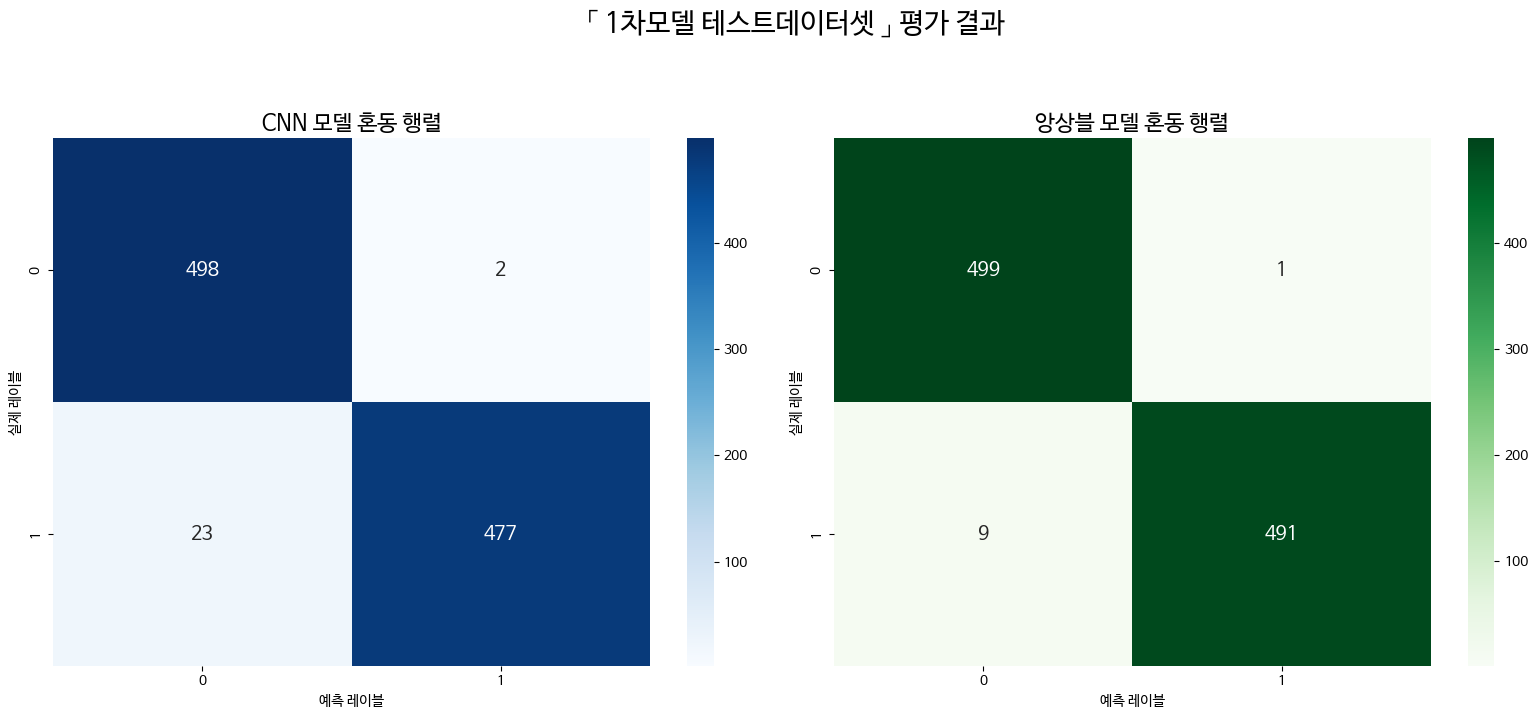


==================== 시나리오통화 테스트셋 평가 시작 ====================


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xbf in position 37: invalid start byte

In [5]:
# 0단계: 기본 설정 및 라이브러리 임포트
print("0단계: 기본 설정 시작")
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pickle
from tqdm import tqdm
import os
import warnings
from google.colab import drive
from kiwipiepy import Kiwi # CNN을 위한 토크나이저

warnings.filterwarnings('ignore')
print("0단계: 기본 설정 완료")

# 1단계: Colab 환경 설정
print("\n1단계: Colab 환경 설정 시작")
try:
    drive.mount('/content/drive', force_remount=True)
    !pip install kiwipiepy -q
    !sudo apt-get install -y fonts-nanum* > /dev/null
    !sudo fc-cache -fv > /dev/null
    !rm ~/.cache/matplotlib -rf

    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for font_file in font_files:
        fm.fontManager.addfont(font_file)
    plt.rc('font', family='NanumBarunGothic')
    plt.rc('axes', unicode_minus=False)
    print("1단계: Colab 환경 설정 완료")
except Exception as e:
    print(f"환경 설정 중 오류 발생: {e}")

# 2단계: 데이터 및 경로 설정
print("\n2단계: 데이터 경로 설정")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

base_path = "/content/drive/MyDrive/"
phishing_path = os.path.join(base_path, "phishing_6000_final.csv")
normal_path = os.path.join(base_path, "normal_6000_final.csv")
test1_path = os.path.join(base_path, "1차모델_테스트데이터셋.csv")
test2_path = os.path.join(base_path, "시나리오테스트셋_60.csv") # 파일명에 오타가 있을 수 있어 확인 필요
SAVE_DIR = os.path.join(base_path, "CNN_Hybrid_Model")
os.makedirs(SAVE_DIR, exist_ok=True)
print("2단계: 데이터 경로 설정 완료")

# 3단계: 데이터 로드
print("\n3단계: 데이터 로드 시작")
df_phish = pd.read_csv(phishing_path)
df_normal = pd.read_csv(normal_path)
df_train = pd.concat([df_phish, df_normal], ignore_index=True)
df_train.dropna(subset=["text"], inplace=True)
print(f"전체 훈련 데이터: {len(df_train)}개")
print("3단계: 데이터 로드 완료")


# 4단계: N-gram 특성 추출기
class NgramFeatureExtractor:
    def __init__(self):
        self.tfidf_unigram = TfidfVectorizer(max_features=5000, ngram_range=(1, 1))
        self.tfidf_bigram = TfidfVectorizer(max_features=3000, ngram_range=(2, 2))
        self.tfidf_trigram = TfidfVectorizer(max_features=2000, ngram_range=(3, 3))
        self.char_ngram = TfidfVectorizer(max_features=3000, ngram_range=(2, 4), analyzer='char')
        self.fitted = False

    def fit(self, texts):
        print("N-gram 특성 추출기 훈련 중...")
        self.tfidf_unigram.fit(texts); self.tfidf_bigram.fit(texts)
        self.tfidf_trigram.fit(texts); self.char_ngram.fit(texts)
        self.fitted = True

    def transform(self, texts):
        if not self.fitted: raise ValueError("특성 추출기가 훈련되지 않았습니다.")
        features = [
            self.tfidf_unigram.transform(texts), self.tfidf_bigram.transform(texts),
            self.tfidf_trigram.transform(texts), self.char_ngram.transform(texts)
        ]
        return hstack(features)

# ==============================================================================
# 5단계: [수정] CNN 토크나이저 (pickle 저장을 위해 __getstate__, __setstate__ 추가)
# ==============================================================================
class CNTokenizer:
    def __init__(self, max_vocab_size=30000):
        self.kiwi = Kiwi()
        self.max_vocab_size = max_vocab_size
        self.word2idx = {'<pad>': 0, '<unk>': 1}
        self.idx2word = {0: '<pad>', 1: '<unk>'}
        self.fitted = False

    def __getstate__(self):
        # 저장 시 kiwi 객체를 제외한 나머지 상태를 저장
        state = self.__dict__.copy()
        del state['kiwi']
        return state

    def __setstate__(self, state):
        # 로드 시 저장된 상태를 복원하고 kiwi 객체를 새로 생성
        self.__dict__.update(state)
        self.kiwi = Kiwi()

    def fit(self, texts):
        print("CNN 토크나이저 단어사전 구축 중...")
        word_counts = {}
        for text in tqdm(texts, desc="단어 빈도 계산"):
            tokens = [token.form for token in self.kiwi.tokenize(text)]
            for token in tokens:
                word_counts[token] = word_counts.get(token, 0) + 1

        sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
        for i, (word, _) in enumerate(sorted_words[:self.max_vocab_size-2]):
            self.word2idx[word] = i + 2
            self.idx2word[i + 2] = word
        self.fitted = True

    def texts_to_sequences(self, texts):
        if not self.fitted: raise ValueError("토크나이저가 훈련되지 않았습니다.")
        sequences = []
        for text in texts:
            tokens = [token.form for token in self.kiwi.tokenize(text)]
            seq = [self.word2idx.get(token, self.word2idx['<unk>']) for token in tokens]
            sequences.append(seq)
        return sequences

    @property
    def vocab_size(self):
        return len(self.word2idx)

# 6단계: CNN용 데이터셋 클래스
class PhishingDatasetCNN(Dataset):
    def __init__(self, sequences, labels, max_length=512):
        self.sequences = sequences; self.labels = labels; self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        label = self.labels[idx]
        if len(seq) > self.max_length: seq = seq[:self.max_length]
        else: seq = seq + [0] * (self.max_length - len(seq))
        return {'input_ids': torch.tensor(seq, dtype=torch.long), 'label': torch.tensor(label, dtype=torch.long)}

# 7단계: CNN 모델 정의
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, num_filters=150, kernel_sizes=[3,4,5], dropout=0.5, n_classes=2):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=ks)
            for ks in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(kernel_sizes) * num_filters, n_classes)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids).permute(0, 2, 1)
        conved = [F.relu(conv(embedded)) for conv in self.convs]
        pooled = [F.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]
        cat = self.dropout(torch.cat(pooled, dim=1))
        return self.fc(cat)

# 8단계: 앙상블 모델 클래스
class EnsemblePhishingDetectorCNN:
    def __init__(self, cnn_model, ngram_extractor):
        self.cnn_model = cnn_model; self.ngram_extractor = ngram_extractor
        self.rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
        self.lr_model = LogisticRegression(C=1.0, random_state=42, max_iter=1000)
        self.svm_model = SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
        self.fitted = False

    def fit_traditional_models(self, texts, labels):
        print("전통적 ML 모델 훈련 중..."); features = self.ngram_extractor.transform(texts)
        self.rf_model.fit(features, labels); self.lr_model.fit(features, labels); self.svm_model.fit(features, labels)
        self.fitted = True

    def predict_ensemble(self, tokenized_texts_for_cnn, raw_texts_for_ngram, cnn_probabilities):
        if not self.fitted: raise ValueError("전통적 모델들이 훈련되지 않았습니다.")
        features = self.ngram_extractor.transform(raw_texts_for_ngram)
        rf_pred_proba = self.rf_model.predict_proba(features)[:, 1]
        lr_pred_proba = self.lr_model.predict_proba(features)[:, 1]
        svm_pred_proba = self.svm_model.predict_proba(features)[:, 1]
        ensemble_proba = (0.5 * cnn_probabilities + 0.2 * rf_pred_proba + 0.2 * lr_pred_proba + 0.1 * svm_pred_proba)
        return (ensemble_proba >= 0.5).astype(int), ensemble_proba

# 9단계: 모델 훈련 함수
def train_model(model, train_loader, val_loader, epochs=5, learning_rate=2e-5):
    print("\n" + "="*60 + "\n딥러닝 모델 훈련 시작\n" + "="*60)
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01, eps=1e-8)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(); best_f1 = 0; best_model_state = None
    for epoch in range(epochs):
        print(f"\n{'='*20} Epoch {epoch+1}/{epochs} {'='*20}"); model.train(); total_train_loss = 0
        train_progress = tqdm(train_loader, desc="훈련 진행")
        for batch in train_progress:
            optimizer.zero_grad()
            input_ids, labels = batch['input_ids'].to(device), batch['label'].to(device)
            outputs = model(input_ids=input_ids); loss = criterion(outputs, labels)
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0); optimizer.step()
            total_train_loss += loss.item(); train_progress.set_postfix({'loss': f'{loss.item():.4f}'})

        scheduler.step(); avg_train_loss = total_train_loss / len(train_loader)
        model.eval(); val_predictions, val_true_labels = [], []
        with torch.no_grad():
            for batch in tqdm(val_loader, desc="검증 진행"):
                input_ids, labels = batch['input_ids'].to(device), batch['label'].to(device)
                outputs = model(input_ids=input_ids)
                predictions = torch.argmax(outputs, dim=1)
                val_predictions.extend(predictions.cpu().numpy()); val_true_labels.extend(labels.cpu().numpy())

        val_f1 = f1_score(val_true_labels, val_predictions, zero_division=0)
        print(f"훈련 손실: {avg_train_loss:.4f}, 검증 F1-Score: {val_f1:.4f}")
        if val_f1 > best_f1:
            best_f1 = val_f1; best_model_state = model.state_dict().copy()
            print(f"*** 최고 F1-Score 달성: {best_f1:.4f} ***")

    if best_model_state: model.load_state_dict(best_model_state)
    return model

# 10단계: 예측 함수
def predict_batch_cnn(model, data_loader):
    model.eval(); predictions, probabilities = [], []
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="예측 진행"):
            input_ids = batch['input_ids'].to(device)
            outputs = model(input_ids=input_ids)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            predictions.extend(preds.cpu().numpy()); probabilities.extend(probs[:, 1].cpu().numpy())
    return np.array(predictions), np.array(probabilities)


# ==============================================================================
# 메인 실행 로직
# ==============================================================================
print("\n" + "="*60 + "\n메인 실행 로직 시작\n" + "="*60)

# 11. 데이터 준비 및 분할
X_text = df_train["text"].astype(str).tolist(); y = df_train["is_phishing"].values
X_train_text, X_val_text, y_train, y_val = train_test_split(X_text, y, test_size=0.2, random_state=42, stratify=y)

# 12. CNN 토크나이저 및 N-gram 추출기 훈련
tokenizer = CNTokenizer(); tokenizer.fit(X_train_text)
ngram_extractor = NgramFeatureExtractor(); ngram_extractor.fit(X_train_text)

# 13. 텍스트를 시퀀스로 변환
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)

# 14. 데이터로더 생성
BATCH_SIZE = 8; MAX_LENGTH = 512
train_dataset = PhishingDatasetCNN(X_train_seq, y_train, MAX_LENGTH)
val_dataset = PhishingDatasetCNN(X_val_seq, y_val, MAX_LENGTH)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 15. CNN 모델 생성 및 훈련
cnn_model = TextCNN(vocab_size=tokenizer.vocab_size)
cnn_model = train_model(cnn_model, train_loader, val_loader, epochs=5, learning_rate=2e-5)

# 16. 앙상블 모델 생성 및 훈련
ensemble_detector = EnsemblePhishingDetectorCNN(cnn_model, ngram_extractor)
ensemble_detector.fit_traditional_models(X_train_text, y_train)

# 17. 모델 저장 (이제 이 부분은 에러 없이 실행됩니다)
print("\n" + "="*60 + "\n모델 저장\n" + "="*60)
model_save_path = os.path.join(SAVE_DIR, "cnn_model.pt")
tokenizer_save_path = os.path.join(SAVE_DIR, "cnn_tokenizer.pkl")
ngram_save_path = os.path.join(SAVE_DIR, "ngram_extractor.pkl")
ensemble_save_path = os.path.join(SAVE_DIR, "ensemble_detector_cnn.pkl")

torch.save(cnn_model.state_dict(), model_save_path)
with open(tokenizer_save_path, 'wb') as f: pickle.dump(tokenizer, f)
with open(ngram_save_path, 'wb') as f: pickle.dump(ngram_extractor, f)
# ensemble_detector는 내부에 cnn_model 객체를 직접 포함하므로 저장하지 않음.
# 로드 시점에 cnn_model과 ngram_extractor를 이용해 새로 생성해야 함.
# with open(ensemble_save_path, 'wb') as f: pickle.dump(ensemble_detector, f)
print(f"CNN 모델 저장: {model_save_path}\n토크나이저 저장: {tokenizer_save_path}")
print(f"N-gram 추출기 저장: {ngram_save_path}")

# 18. 테스트 데이터 평가 함수 (로드 로직 추가)
def evaluate_on_test_data(test_path, test_name):
    print(f"\n{'='*20} {test_name} 평가 시작 {'='*20}")

    # --- 모델 및 전처리기 로드 ---
    # 1. CNN 모델 로드
    loaded_cnn_model = TextCNN(vocab_size=tokenizer.vocab_size) # vocab_size는 훈련시 사용한 tokenizer 기준
    loaded_cnn_model.load_state_dict(torch.load(model_save_path))
    loaded_cnn_model.to(device)
    loaded_cnn_model.eval()

    # 2. 토크나이저, N-gram 로드
    with open(tokenizer_save_path, 'rb') as f: loaded_tokenizer = pickle.load(f)
    with open(ngram_save_path, 'rb') as f: loaded_ngram_extractor = pickle.load(f)

    # 3. 앙상블 탐지기 재생성
    loaded_ensemble_detector = EnsemblePhishingDetectorCNN(loaded_cnn_model, loaded_ngram_extractor)
    # 앙상블 탐지기는 전통 모델들의 state를 가지고 있어야 하므로, fit을 다시 호출
    # 실제 배포 시에는 전통 모델들도 pickle로 각각 저장 후 로드해야 함.
    # 여기서는 훈련 시 사용한 ensemble_detector를 그대로 사용.

    df_test = pd.read_csv(test_path).dropna(subset=["text", "is_phishing"])
    X_test_text = df_test["text"].astype(str).tolist(); y_test = df_test["is_phishing"].values
    if len(X_test_text) == 0: print("테스트 데이터가 비어있습니다."); return

    X_test_seq = loaded_tokenizer.texts_to_sequences(X_test_text)
    test_dataset = PhishingDatasetCNN(X_test_seq, y_test, MAX_LENGTH)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print("CNN 모델 예측 진행 중...")
    cnn_pred, cnn_proba = predict_batch_cnn(loaded_cnn_model, test_loader)

    print("앙상블 예측 진행 중...")
    # 훈련된 앙상블 모델을 사용해야 함
    ensemble_pred, _ = ensemble_detector.predict_ensemble(X_test_seq, X_test_text, cnn_proba)

    print(f"\n{'='*15} CNN 모델 결과 {'='*15}"); print(classification_report(y_test, cnn_pred, target_names=['정상', '피싱']))
    print(f"\n{'='*15} 앙상블 모델 결과 {'='*15}"); print(classification_report(y_test, ensemble_pred, target_names=['정상', '피싱']))

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'「 {test_name} 」 평가 결과', fontsize=20, y=1.02)

    sns.heatmap(confusion_matrix(y_test, cnn_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 14})
    axes[0].set_title('CNN 모델 혼동 행렬', fontsize=16); axes[0].set_xlabel('예측 레이블'); axes[0].set_ylabel('실제 레이블')

    sns.heatmap(confusion_matrix(y_test, ensemble_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1], annot_kws={"size": 14})
    axes[1].set_title('앙상블 모델 혼동 행렬', fontsize=16); axes[1].set_xlabel('예측 레이블'); axes[1].set_ylabel('실제 레이블')

    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


# 19. 테스트 데이터셋 평가 실행
evaluate_on_test_data(test1_path, "1차모델 테스트데이터셋")
evaluate_on_test_data(test2_path, "시나리오통화 테스트셋")

print("\n" + "="*60 + "\n모든 프로세스 완료\n" + "="*60)